In [1]:
import matplotlib.pyplot as plt

In [2]:
import numpy as np

In [3]:
import scipy

In [4]:
import scipy.stats as stats

In [5]:
import sklearn.cluster as skcl
import seaborn as sns

In [6]:
import pandas as pd

data = pd.read_csv('/content/flights_NY.csv')
data

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance
0,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400
1,2013,1,1,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416
2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089
3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576
4,2013,1,1,554.0,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,116.0,762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,2013,9,30,NaN,NaN,NaN,NaN,9E,NaN,3393,JFK,DCA,NaN,213
336772,2013,9,30,NaN,NaN,NaN,NaN,9E,NaN,3525,LGA,SYR,NaN,198
336773,2013,9,30,NaN,NaN,NaN,NaN,MQ,N535MQ,3461,LGA,BNA,NaN,764
336774,2013,9,30,NaN,NaN,NaN,NaN,MQ,N511MQ,3572,LGA,CLE,NaN,419


Удалим строки, содержащие NaN

In [7]:
 n_data = data.dropna()
 n_data

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance
0,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400
1,2013,1,1,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416
2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089
3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576
4,2013,1,1,554.0,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,116.0,762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336765,2013,9,30,2240.0,-5.0,2334.0,-17.0,B6,N354JB,1816,JFK,SYR,41.0,209
336766,2013,9,30,2240.0,-10.0,2347.0,-20.0,B6,N281JB,2002,JFK,BUF,52.0,301
336767,2013,9,30,2241.0,-5.0,2345.0,-16.0,B6,N346JB,486,JFK,ROC,47.0,264
336768,2013,9,30,2307.0,12.0,2359.0,1.0,B6,N565JB,718,JFK,BOS,33.0,187


# Задание 1
**Выберите 10 аэропортов, в которые чаще всего летают из Нью-Йорка. Для каждого  из них оцените вероятность, что рейс прилетит с положительной задержкой (arr_delay > 0) и постройте график (столбчатая диаграмма), на котором по оси х – название аэропорта, по оси y – вероятность задержки прилета. Названия аэропортов по оси х расположите слева направо по убыванию количества рейсов в этот аэропорт. Для какого аэропорта из этих 10 вероятность окажется наибольшей, и для какого – наименьшей?**

Получим список 10 аэропортов, в которые чаще всего летают из Нью-Йорка

In [8]:
ny_10 = n_data.groupby('dest').size().nlargest(n=10)
ny_10

,0
dest,
ATL,16837
ORD,16566
LAX,16026
BOS,15022
MCO,13967
CLT,13674
SFO,13173
FLL,11897
MIA,11593


Получили, что это следующие аэропорты:

In [9]:
ser = ny_10.index.to_list()
ser

['ATL', 'ORD', 'LAX', 'BOS', 'MCO', 'CLT', 'SFO', 'FLL', 'MIA', 'DCA']

In [11]:
n10_n_data = n_data[n_data.dest.isin(ser)]
n10_n_data

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance
2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089
4,2013,1,1,554.0,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,116.0,762
5,2013,1,1,554.0,-4.0,740.0,12.0,UA,N39463,1696,EWR,ORD,150.0,719
6,2013,1,1,555.0,-5.0,913.0,19.0,B6,N516JB,507,EWR,FLL,158.0,1065
8,2013,1,1,557.0,-3.0,838.0,-8.0,B6,N593JB,79,JFK,MCO,140.0,944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336754,2013,9,30,2147.0,10.0,30.0,3.0,B6,N627JB,1371,LGA,FLL,139.0,1076
336755,2013,9,30,2149.0,-7.0,2245.0,-23.0,UA,N813UA,523,EWR,BOS,37.0,200
336762,2013,9,30,2233.0,80.0,112.0,42.0,UA,N578UA,471,EWR,SFO,318.0,2565
336763,2013,9,30,2235.0,154.0,59.0,130.0,B6,N804JB,1083,JFK,MCO,123.0,944


Для каждого  из них оценим вероятность, что рейс прилетит с положительной задержкой (arr_delay > 0). Для этого преобразуем значения по задержке прилета в 1, если они больше 0 или в 0, если меньше или равно 0.

In [12]:
n10_n_data['delay'] = (n10_n_data.arr_delay > 0).astype(int)
n10_n_data.delay

<ipython-input-12-214cd4159ef8>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  n10_n_data['delay'] = (n10_n_data.arr_delay > 0).astype(int)


,delay
2,1
4,0
5,1
6,1
8,0
...,...
336754,1
336755,0
336762,1
336763,1


Посчитаем число рейсов с положительной задержкой

In [13]:
delay_data = n10_n_data.groupby('dest').delay.sum()
delay_data = pd.DataFrame(delay_data)
delay_data

,delay
dest,
ATL,7946
BOS,4743
CLT,5838
DCA,4003
FLL,5212
LAX,5967
MCO,5545
MIA,3855
ORD,6198


Посчитаем общее число рейсов

In [14]:
delay_new = delay_data.merge(pd.DataFrame(ny_10, columns=['number']), on = 'dest')
delay_new

,delay,number
dest,,
ATL,7946,16837
BOS,4743,15022
CLT,5838,13674
DCA,4003,9111
FLL,5212,11897
LAX,5967,16026
MCO,5545,13967
MIA,3855,11593
ORD,6198,16566


Найдем вероятность, что рейс прилетит с положительной задержкой

In [15]:
delay_new['probability'] = (delay_new.delay / delay_new.number)
n_delay_new = delay_new.sort_values('number', ascending=False)
n_delay_new

,delay,number,probability
dest,,,
ATL,7946,16837,0.471937
ORD,6198,16566,0.374140
LAX,5967,16026,0.372332
BOS,4743,15022,0.315737
MCO,5545,13967,0.397007
CLT,5838,13674,0.426942
SFO,4941,13173,0.375085
FLL,5212,11897,0.438094
MIA,3855,11593,0.332528


Построим столбчатую диаграмму, где Ох – название аэропорта, Оу – вероятность задержки прилета.

Text(0, 0.5, 'Вероятность задержки прилета')

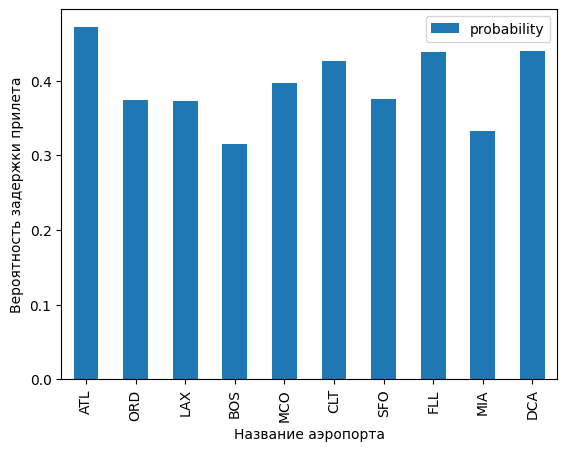

In [16]:
n_delay_new.plot.bar(y = 'probability')
plt.xlabel('Название аэропорта')
plt.ylabel('Вероятность задержки прилета')

Найдем, для какого из этих 10 аэропортов вероятность окажется наибольшей, и для какого – наименьшей

In [18]:
display('Наибольшая вероятность опозданий', delay_new.iloc[delay_new['probability'].argmax()])
display('Наименьшая вероятность опозданий', delay_new.iloc[delay_new['probability'].argmin()])

'Наибольшая вероятность опозданий'

,ATL
delay,7946.000000
number,16837.000000
probability,0.471937


'Наименьшая вероятность опозданий'

,BOS
delay,4743.000000
number,15022.000000
probability,0.315737


Видим, что наибольшая вероятность опоздания - ATL, наименьшая - BOS.

# Задание 2
**Постройте нормированную гистограмму распределения времени перелета из Нью-Йорка в Сан-Франциско (SFO). Предполагая, что это распределение описывается нормальным законом, оцените параметры нормального закона и наложите график плотности полученного нормального закона на график с гистограммой. В каких пределах с вероятностью не менее 95% лежит время полета?**

Чтобы построить гистрограмму распределения времени перелета из Нью-Йорка в Сан-Франциско, получим таблицу, где содержится информация только о рейсах в Сан-Франциско (SFO).

In [19]:
SFO_data = n_data[n_data.dest == 'SFO']
SFO_data

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance
13,2013,1,1,558.0,-2.0,923.0,-14.0,UA,N53441,1124,EWR,SFO,361.0,2565
26,2013,1,1,611.0,11.0,945.0,14.0,UA,N532UA,303,JFK,SFO,366.0,2586
55,2013,1,1,655.0,-5.0,1037.0,-8.0,DL,N705TW,1865,JFK,SFO,362.0,2586
82,2013,1,1,729.0,-1.0,1049.0,-26.0,VX,N635VA,11,JFK,SFO,356.0,2586
87,2013,1,1,734.0,-3.0,1047.0,-26.0,B6,N625JB,643,JFK,SFO,350.0,2586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336658,2013,9,30,1938.0,48.0,2248.0,28.0,VX,N626VA,29,JFK,SFO,323.0,2586
336662,2013,9,30,1940.0,40.0,2228.0,-4.0,DL,N723TW,1465,JFK,SFO,323.0,2586
336679,2013,9,30,2001.0,1.0,2302.0,-26.0,UA,N35260,1651,EWR,SFO,323.0,2565
336701,2013,9,30,2023.0,-2.0,2315.0,-35.0,B6,N712JB,915,JFK,SFO,327.0,2586


Получим нормированную гистограмму распределения времени перелета из Нью-Йорка в Сан-Франциско (SFO).

array([[<Axes: title={'center': 'air_time'}>]], dtype=object)

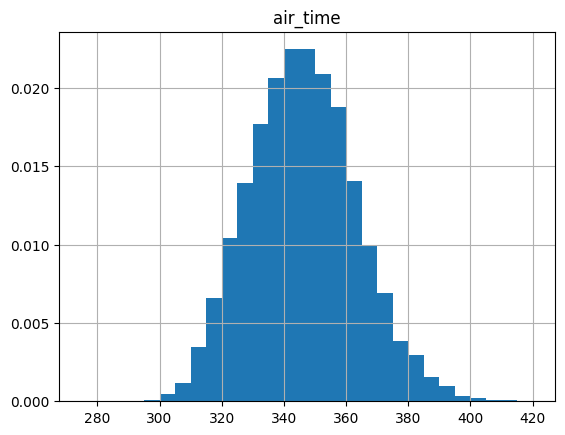

In [173]:
SFO_data.hist('air_time', bins = np.arange(275, 425, 5), density = True)

Оценим параметры нормального закона: математическое ожидание и стандартное отклонение.

In [21]:
aver = SFO_data.air_time.mean()
aver

np.float64(345.6831397555606)

Мат. ожидание составляет около 346

In [22]:
st = SFO_data.air_time.std()
st

17.234986172190037

Ст. отклонение составляет около 17

Наложим график плотности полученного нормального закона на график с гистограммой

array([<Axes: title={'center': 'air_time'}>], dtype=object)

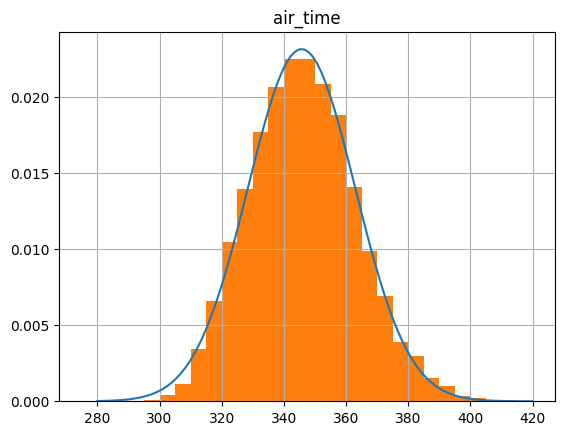

In [23]:
fig,ax = plt.subplots()
x = np.linspace(280, 420, 100)
ax.plot(x, stats.norm.pdf(x, aver, st))

SFO_data.hist('air_time', bins = np.arange(275, 425, 5), ax = ax, density = True)

Найдем, в каких пределах с вероятностью не менее 95% лежит время полета. Для этого воспользуемся правилом 3 сигм.


In [24]:
#Правило трех сигм: [μ - 2σ, μ + 2σ]

left_border = aver - 2*st
right_border = aver + 2*st

print(left_border, right_border)

311.2131674111805 380.1531120999407


То есть, 95% значений лежит в интервале от 311 до 380.

# Задание 3
**Нарисуйте распределение по часам (0-23) количества вылетов из аэропорта JFK и найдите два пиковых часа (один до полудня, другой – после полудня) по количеству вылетов (время вылета переводите в час вылета округлением вниз, например 7:20 -> 7, 16:45 -> 16). Для каждого из двух найденных пиковых часов найдите среднее время задержки вылетов в этот час. Когда средняя задержка больше? Будет ли это различие в средних значениях статистически значимо?**

Отформатируем исходную таблицу так, чтобы она содержала только информацию о вылетах из аэропорта JFK. Так же оторматируем время отправления ('dep_time') так, чтобы оно содержало только часы (так как этого требует задание). Под # указан код, который использовался изначально, предполагая, что время указано только в формате HHMM или HMM. В ходе выполения задания было получено, что, на самом деле, в таблице есть значения, состоящие из 1 и двух знаков. С учетом этого был написан использующийся другой код.

In [161]:
JFK_data = n_data[n_data.origin == 'JFK']
# JFK_data.dep_time = JFK_data.dep_time.astype(str).apply(lambda x: x[0] if len(x) == 5 else x[:2]).astype(int)

JFK_data.dep_time = n_data[n_data.origin == 'JFK'].dep_time.map(lambda x: 0 if x <= 60 else x).astype(int).astype(str).map(lambda x: x[0] if len(x) == 3 else x[:2]).astype(int).map(lambda x: 0 if x == 24 else x).sort_values()

<ipython-input-161-10d6205bc982>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  JFK_data.dep_time = n_data[n_data.origin == 'JFK'].dep_time.map(lambda x: 0 if x <= 60 else x).astype(int).astype(str).map(lambda x: x[0] if len(x) == 3 else x[:2]).astype(int).map(lambda x: 0 if x == 24 else x).sort_values()


Нарисуем распределение числа вылетов в разные часы суток.

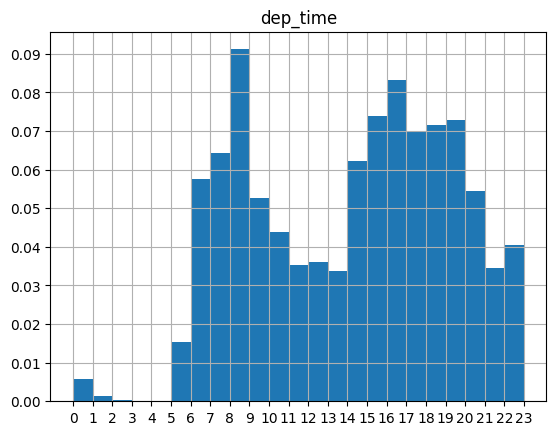

In [162]:
JFK_data.hist('dep_time', bins = np.arange(0, 24, 1), density = True)
plt.xticks(np.arange(24))
plt.yticks(np.arange(0, 0.1, 0.01))
plt.show()

Найдем пиковые часы вылетов до и после полудня. Для этого получим маску для вылетов до полудня и после - time_before и time_after, соответственно. После наложим ее на саму таблицу и посчитаем число вылетов для каждого часа.

In [163]:
time_before = (JFK_data.dep_time < 13)
time_before_data = JFK_data[time_before]
time_max_before = time_before_data.groupby('dep_time').size()
time_max_before

,0
dep_time,
0,619
1,136
2,47
3,11
5,1679
6,6269
7,7011
8,9946
9,5749


Видим, что пиковый час по вылетам до полудня - 8 утра.

In [164]:
time_after = (JFK_data.dep_time > 12)
time_after_data = JFK_data[time_after]
time_max_after = time_after_data.groupby('dep_time').size()
time_max_after

,0
dep_time,
13,3668
14,6788
15,8065
16,9082
17,7597
18,7818
19,7939
20,5929
21,3760


Видим, что пиковый час по вылетам после полудня - 16 часов.

Найдем среднее время задержки вылетов для каждого из двух найденных пиковых часов.

In [170]:
time_b_data = JFK_data[(JFK_data.dep_time == 8)]
time_a_data = JFK_data[(JFK_data.dep_time == 16)]

mean_b = time_b_data.dep_delay.mean()
print('Средняя задержка в пиковый час до полудня: ', mean_b)
mean_a = time_a_data.dep_delay.mean()
print('Средняя задержка в пиковый час после полудня: ', mean_a)

Средняя задержка в пиковый час до полудня:  1.0374019706414639
Средняя задержка в пиковый час после полудня:  10.867650297291345


Видим, что средняя задержка больше после полудня.

Оценим, будет ли такое различие статистически значимо при помощи t-теста. Н0 - средние задержки для выборок вылетов до и после полудня равны. Н1 - они не равны.

In [172]:
stats.ttest_ind(time_b_data.dep_delay.to_numpy(), time_a_data.dep_delay.to_numpy())

TtestResult(statistic=np.float64(-28.523460705975232), pvalue=np.float64(2.883608900905687e-175), df=np.float64(19026.0))

То есть, отклоняем нулевую гипотезу. Следовательно, различие между средними задержками действительно статистически значимо.

# Задание 4
**Для каждого аэропорта прилета найдите величину стандартного отклонения времени перелета. Постройте график (точечная диаграмма) зависимости стандартного отклонения от расстояния до аэропорта. Аппроксимируйте полученную зависимость моделью линейной регрессии на основе расстояния до аэропорта  Добавьте к предыдущему графику график линейной регрессии. Уточните модель линейной регрессии, используя дополнительные входные признаки на основе расстояния до аэропорта. Добавьте график уточненной модели. Сравните точность моделей.**

Получим значение стандартного отклонения времени перелета для каждого из аэропортов.

In [174]:
st = n_data.groupby('dest').air_time.std()
st_t = pd.DataFrame(st)
st_t = st_t.reset_index()
st_t_map = dict(zip(st_t.dest, st_t.air_time))
st_t_map

{'ABQ': 19.29137107400051,
 'ACK': 8.127494697978936,
 'ALB': 3.0847541243600736,
 'ANC': 14.672009308300527,
 'ATL': 9.812387008998204,
 'AUS': 18.22418610225566,
 'AVL': 7.379748217973542,
 'BDL': 3.2854928014724307,
 'BGR': 3.329299783253831,
 'BHM': 10.497088633402413,
 'BNA': 10.960875990491045,
 'BOS': 4.948552434821855,
 'BQN': 9.163294985656627,
 'BTV': 3.9572836167143888,
 'BUF': 5.231471008343903,
 'BUR': 18.6431397393859,
 'BWI': 4.350573642096774,
 'BZN': 12.667897625577059,
 'CAE': 8.299649804798998,
 'CAK': 4.780790270673666,
 'CHO': 5.15948542541526,
 'CHS': 8.353412834263603,
 'CLE': 6.932541426302247,
 'CLT': 8.897082380188737,
 'CMH': 6.596712209496218,
 'CRW': 6.319127863070764,
 'CVG': 8.52366805126372,
 'DAY': 7.37990104947285,
 'DCA': 6.46027722970907,
 'DEN': 15.462579965355026,
 'DFW': 17.233627958528388,
 'DSM': 13.113564853768636,
 'DTW': 7.8539279162849365,
 'EGE': 17.374784025383157,
 'EYW': 11.518846449597792,
 'FLL': 12.274765925155092,
 'GRR': 8.601845552

Добавим в таблицу колонку air_time_y, которая содержит среднее отклонение времени перелета. Также удалим аэропорты, для которых соответствуеющее значение - NaN.

In [26]:
n_data['air_time_y'] = n_data.dest.map(lambda x: st_t_map[x])
ndropdata = n_data.dropna()

<ipython-input-26-2b6930d572e3>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  n_data['air_time_y'] = n_data.dest.map(lambda x: st_t_map[x])


Построим график (точечная диаграмма) зависимости стандартного отклонения от расстояния до аэропорта. Для этого преобразуем таблицу так, чтобы она содержала только информацию о стандартном отклонении (air_time_y) и расстоянии до аэропорта (distance). Для удобства кратко назовем значения для каждого признака как х и у.

In [27]:
st_t_d = ndropdata[['distance', 'air_time_y']]
x =  st_t_d.distance.to_numpy()
y =  st_t_d.air_time_y.to_numpy()

Собственно, построим точечную диаграмму.

<Axes: xlabel='distance', ylabel='air_time_y'>

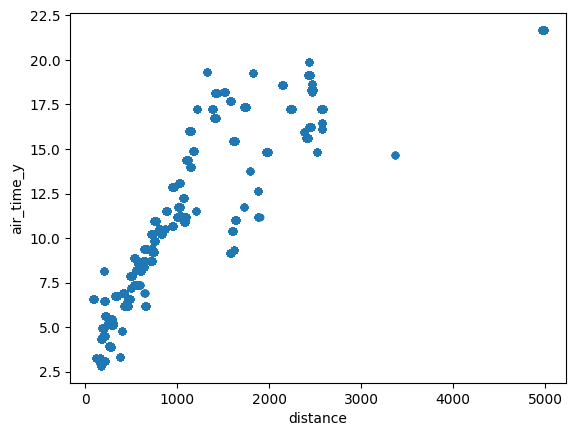

In [28]:
st_t_d.plot.scatter(x='distance', y='air_time_y')

Аппроксимируем полученную зависимость моделью линейной регрессии на основе расстояния до аэропорта. Добавим полученный график к предыдущему.

<Axes: xlabel='distance', ylabel='air_time_y'>

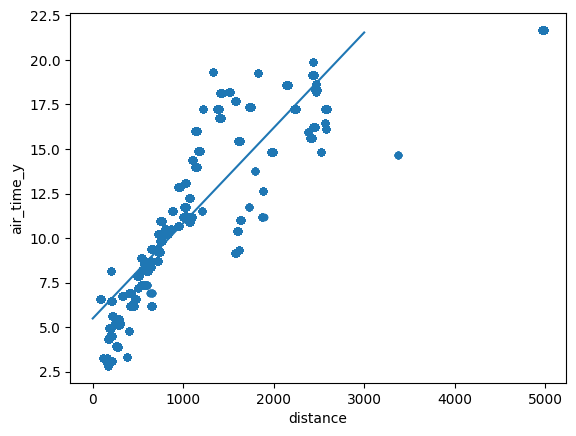

In [189]:
import sklearn as sk

linreg = sk.linear_model.LinearRegression()
linreg.fit(x.reshape(-1, 1), y.reshape(-1, 1))

pred_x = np.linspace(0, 3000, 10000)
pred_y = linreg.predict(pred_x.reshape(-1, 1)).flatten()

fig, ax = plt.subplots()
ax.plot(pred_x, pred_y)
st_t_d.plot.scatter(x='distance', y='air_time_y', ax=ax)

Уточним модель линейной регрессии. Для этого будем использовать в качестве входного признака логарифм от расстояния до аэропорта

In [190]:
linreg1 = linreg.fit(np.log(x).reshape(-1, 1), y.reshape(-1, 1))

Добавим полученный график уточненнной модели к предыдущему

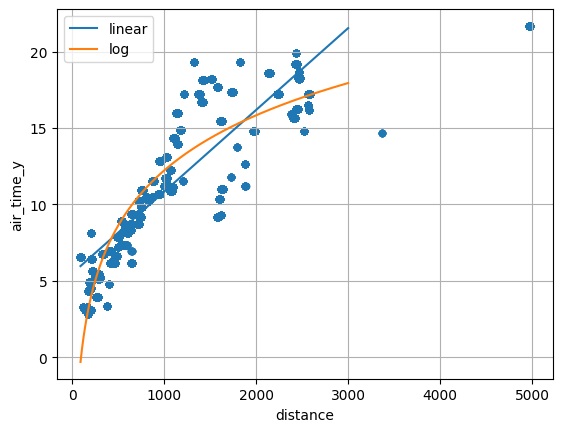

In [86]:
linreg = sk.linear_model.LinearRegression()
linreg.fit(x.reshape(-1, 1), y.reshape(-1, 1))

pred_x = np.linspace(90, 3000, 10000)
pred_y = linreg.predict(pred_x.reshape(-1, 1)).flatten()

pred_y1 = linreg1.predict(np.log(pred_x).reshape(-1, 1)).flatten()

fig, ax = plt.subplots()
ax.plot(pred_x, pred_y, label='linear')
ax.plot(pred_x, pred_y1, label='log')
st_t_d.plot.scatter(x='distance', y='air_time_y', ax=ax)
plt.legend()
plt.grid()

Сравним точность моделей при помощи средней квадратичной ошибки.

In [175]:
from sklearn.metrics import mean_squared_error

lin_error = mean_squared_error(y, linreg.predict(x.reshape(-1, 1)))
log_error = mean_squared_error(y, linreg1.predict(np.log(x).reshape(-1, 1)))

print(lin_error, log_error)

3.3068936506615376 2.7090415757677695


Видим, что средняя квадратичная ошибка для уточненной модели меньше, чем для предыдущей. То есть, новая модель качественнее.

# Задание 5
**Методом кластерного анализа выделите три группы авиакомпаний на основе пары признаков: средняя задержка прилета и средняя задержка вылета. Постройте точечную диаграмму на этих признаках и раскрасьте точки в соответствии с номером кластера. Попробуйте дать интерпретацию кластерам (в этом может помочь название авиакомпании).**


Необходимо методом кластерного анализа выделить три группы авиакомпаний на основе пары признаков: средняя задержка прилета и средняя задержка вылета.

Для этого преобразуем таблицу так, чтобы она содержала только необходимую информацию: авиакомпанию (carrier) среднюю задержку прилета (dep_delay) и среднюю задержку вылета (arr_delay).

In [31]:
carr_means = n_data.groupby('carrier').agg({'dep_delay': np.mean, 'arr_delay': np.mean})
carr_means

<ipython-input-31-6c173625faed>:1: FutureWarning: The provided callable <function mean at 0x7a72d7d0e020> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  carr_means = n_data.groupby('carrier').agg({'dep_delay': np.mean, 'arr_delay': np.mean})
<ipython-input-31-6c173625faed>:1: FutureWarning: The provided callable <function mean at 0x7a72d7d0e020> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  carr_means = n_data.groupby('carrier').agg({'dep_delay': np.mean, 'arr_delay': np.mean})


,dep_delay,arr_delay
carrier,,
9E,16.439574,7.379669
AA,8.569130,0.364291
AS,5.830748,-9.930889
B6,12.967548,9.457973
DL,9.223950,1.644341
EV,19.838929,15.796431
F9,20.201175,21.920705
FL,18.605984,20.115906
HA,4.900585,-6.915205


Начнем кластеризацию.

In [33]:
X = carr_means[['dep_delay', 'arr_delay']].to_numpy()

kmeans = sk.cluster.KMeans(3)
kmeans.fit(X)

KMeans(n_clusters=3)

Визуализируем кластеры, раскрасив точки в соответствии с номером кластера.

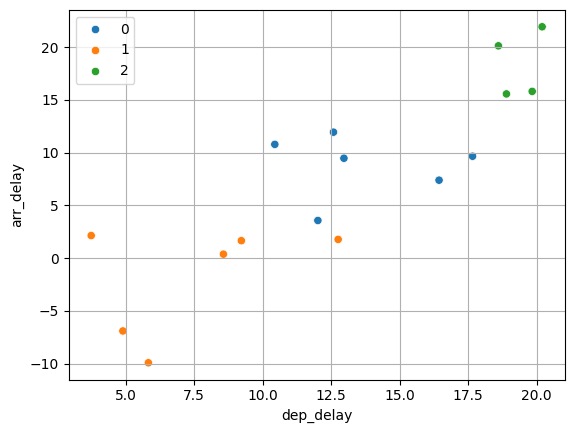

In [34]:
sns.scatterplot(data=carr_means, x='dep_delay', y='arr_delay', hue=kmeans.labels_, palette='tab10')
plt.grid()

In [176]:
with_labels = pd.concat([carr_means.reset_index(), pd.DataFrame(kmeans.labels_, columns=['labels'])], axis=1)

with_labels.groupby('labels').carrier.apply(lambda x: list(x))

,carrier
labels,
0,"[9E, B6, MQ, OO, UA, WN]"
1,"[AA, AS, DL, HA, US, VX]"
2,"[EV, F9, FL, YV]"


Получили, в каком кластере находится какой перевозчик.

Добавим в таблицу колонку с распределением перевозчиков по кластерам.

In [179]:
label_map = dict(zip(with_labels.carrier, with_labels.labels))

n_data['labels'] = n_data.carrier.map(lambda x: label_map[x])

<ipython-input-179-4ab1b62f7263>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  n_data['labels'] = n_data.carrier.map(lambda x: label_map[x])


Попробуем интерпретировать полученные кластеры. Предположим, что чем больше время в пути или расстояние, тем больше будет задержка. Анализировать будем при помощи ядерной оценки плотности.

<Axes: xlabel='distance', ylabel='Density'>

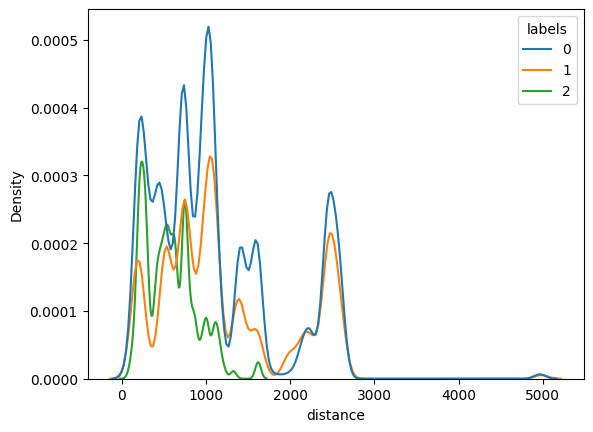

In [186]:
sns.kdeplot(data=n_data, x='distance', hue='labels', palette='tab10')

<Axes: xlabel='air_time', ylabel='Density'>

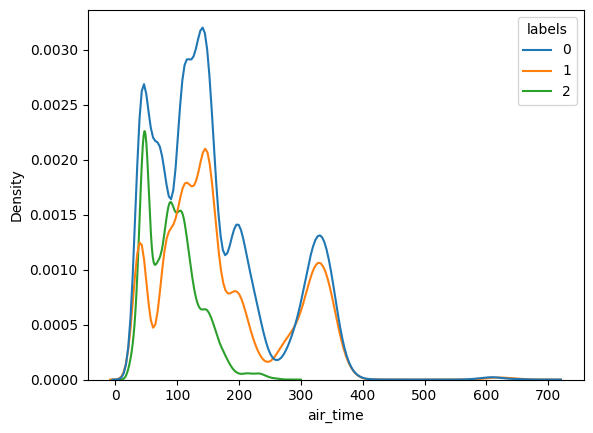

In [187]:
sns.kdeplot(data=n_data, x='air_time', hue='labels', palette='tab10')

Видим, что в обоих случаях заметных отличий по данным признакам внутри кластеров нет.

Методом перебора определили, что отличия будут наблюдаться только по признаку Flight - номеру рейса. Однако так как номер полета, исходя из литературных источников, присваивается случайным образом, интерпретировать кластеры не получилось.

<Axes: xlabel='flight', ylabel='Density'>

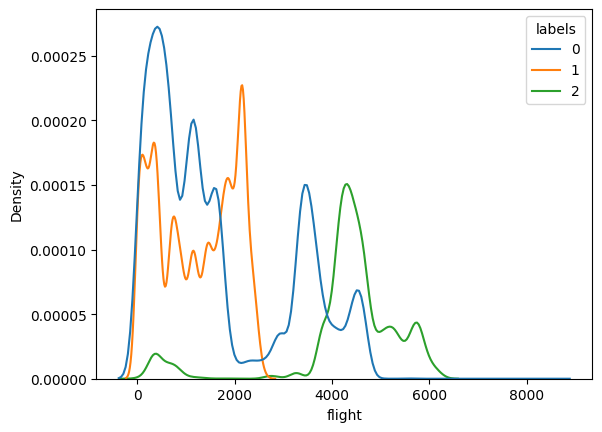

In [185]:
sns.kdeplot(data=n_data, x='flight', hue='labels', palette='tab10')